<a href="https://colab.research.google.com/github/juliagermanosilva-pixel/Fundamentos_de_ci-ncias_de_dados/blob/main/Fundamentos_de_ci%C3%AAncias_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#para o trabalho com coleta de informações
# 1 - entrada manual - usuário informa dados
# 2 - raspagem de dados - web scraping - entra em um site e coleta seus dados
# 3 - importação/automação - sensores, apis ...
#vamos usar web scraping para coletar dados de notícia
import requests
import pandas as pd
#para puxar uma função especifica de uma biblioteca, não precisamos
#dela toda, from biblioteca import função
from datetime import datetime
#temos que importar uma biblioteca de web scraping
from bs4 import BeautifulSoup

In [13]:
def coletar_noticias_g1():
  url_g1 = 'https://g1.globo.com/'

  headers = {
      'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36'
  }

  try:
    resposta = requests.get(url_g1, headers=headers)
    resposta.raise_for_status()

    soup = BeautifulSoup(resposta.text,'html.parser')

    posts_elements = soup.find_all('a', class_='feed-post-link')
    lista_noticias = []
    for i in posts_elements:
      titulo = i.get_text()
      link = i.get('href')
      lista_noticias.append({'Titulo':titulo,
                             'Link':link,
                             'Data':datetime.now().strftime('%d/%m/%Y')})
    df_noticias = pd.DataFrame(lista_noticias)
    return df_noticias
  except Exception as e:
    print(f'Não consegui ler as noticias: {e}')
    return None

In [14]:
noticias = coletar_noticias_g1()
if noticias is not None:
  display(noticias.head(10))

,Titulo,Link,Data
0,"Anderson Neiff, 'rei do brega-funk' baleado, t...",https://g1.globo.com/sp/sao-paulo/noticia/2026...,26/04/2026
1,México diz que agentes dos EUA não eram autori...,https://g1.globo.com/mundo/noticia/2026/04/26/...,26/04/2026
2,VÍDEO: Cabo de brinquedo em parque arrebenta e...,https://g1.globo.com/mundo/noticia/2026/04/26/...,26/04/2026
3,"Nedra Talley, do histórico girl-group Ronettes...",https://g1.globo.com/pop-arte/noticia/2026/04/...,26/04/2026
4,Queniano é 1ª pessoa na história a correr mara...,https://ge.globo.com/atletismo/noticia/2026/04...,26/04/2026
5,O que são os sites de 'apostas sobre tudo' que...,https://g1.globo.com/tecnologia/noticia/2026/0...,26/04/2026
6,El Niño forte reacende alerta de cheias no RS ...,https://g1.globo.com/rs/rio-grande-do-sul/noti...,26/04/2026


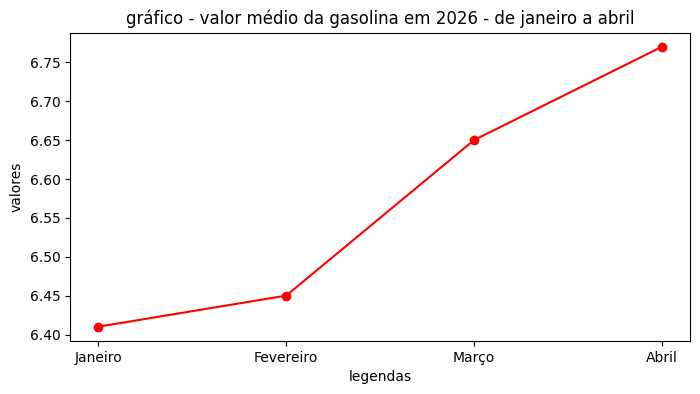

In [16]:
#vamos criar um grafico com o valor médio de gadolina mês a mês em 2026
#para fazer um gráfico precisamos de pelo menos dois eixos
x_mes = ['Janeiro','Fevereiro','Março','Abril']
#precisamos de um eixo de legenda e um eixo de valor, pelo menos
y_preco = [6.41,6.45,6.65,6.77]
#a biblioteca que gera gráficos é matplotlib ou potly
#com matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4)) #dimensionamento da imagem - OPCIONAL
#para gerar o gráfico
#plt.plot(eixo x, eixo y, marker='o', color='COR EM INGLES')
plt.plot(x_mes, y_preco, marker='o', color='red')
plt.title('gráfico - valor médio da gasolina em 2026 - de janeiro a abril')
plt.xlabel('legendas')
plt.ylabel('valores')
plt.show()
